In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_context('notebook')

pal = [
    "#FF1B5E", "#FFDB57", "#438CFD", "#FF8C00", "#80F15E",
    "#03FFFF", "#5941A9", "#E980FC", "#1A1A2E", "#F5F0FF", "#C17F3E",
]

pub_pal = {
    "Bulk": pal[2],
    "PTA": pal[4],
    "MDA": pal[0],
    "mMDA": pal[0],
    "LIANTI": pal[3],
    "MALBAC": pal[1],
    "CapWGS": pal[6],
    "Cell Growth": pal[6],
    "DOP_PCR": pal[5],
}

order_cap = ["mMDA", "PTA", "Cell Growth"]
order_pub = ["PTA", "LIANTI", "MDA", "MALBAC"]

ROOT = Path('..').resolve()
RB = ROOT / 'results/benchmarking'

# --- Gini ---
cap_data = pd.read_csv(RB / 'cap_data.csv')
combined_cov = pd.read_csv(RB / 'combined_coverage.csv', index_col=0)
gini_cap = cap_data[cap_data['amplification_method'].isin(order_cap)][['amplification_method','gini_coefficient']].rename(
    columns={'amplification_method': 'method', 'gini_coefficient': 'value'})
gini_pub = combined_cov[combined_cov['method'].isin(order_pub)][['method','gini']].rename(columns={'gini':'value'})

# --- MAPD ---
cap_pair = pd.read_csv(RB / 'cap_pair.csv', index_col=0)
pub_pair = pd.read_csv(RB / 'pub_pair.csv', index_col=0)
mapd_cap = cap_pair[cap_pair['method'].isin(order_cap)][['method','mapd']].rename(columns={'mapd':'value'})
# Aggregate CapWGS sub-methods into a single CapWGS group on the right
cap_pair_all = cap_pair.assign(method='CapWGS')[['method','mapd']].rename(columns={'mapd':'value'})
mapd_pub = pd.concat([pub_pair[['method','mapd']].rename(columns={'mapd':'value'}), cap_pair_all],
                    ignore_index=True)
mapd_pub = mapd_pub[mapd_pub['method'].isin(order_pub)]

# --- CNV FDR ---
hsc4_bin = pd.read_csv(RB / 'hsc4_bin.csv', index_col=0)
disc_pub_frac = pd.read_csv(RB / 'disc_pub_frac.csv', index_col=0)
cnv_cap = hsc4_bin[hsc4_bin['amplification_method'].isin(order_cap)][['amplification_method','disc_frac_masked']].rename(
    columns={'amplification_method':'method','disc_frac_masked':'value'})
# Aggregate CapWGS HSC4 cells into a single CapWGS group on the right
cnv_capwgs_all = hsc4_bin.assign(method='CapWGS')[['method','disc_frac_masked']].rename(columns={'disc_frac_masked':'value'})
cnv_pub = pd.concat([disc_pub_frac[['wga_method','disc_frac_masked']].rename(
    columns={'wga_method':'method','disc_frac_masked':'value'}), cnv_capwgs_all], ignore_index=True)
cnv_pub = cnv_pub[cnv_pub['method'].isin(order_pub)]

# --- SBS FDR ---
sbs_cap = pd.read_csv(RB / 'SBS_fdr_capwgs.csv', index_col=0)
sbs_pub = pd.read_csv(RB / 'SBS_fdr_pub.csv')
sbs_cap_df = sbs_cap[sbs_cap['amplification_method'].isin(order_cap)][['amplification_method','FP_rate']].rename(
    columns={'amplification_method':'method','FP_rate':'value'})
sbs_pub_df = sbs_pub[sbs_pub['amplification_method'].isin(order_pub)][['amplification_method','fp_fraction']].rename(
    columns={'amplification_method':'method','fp_fraction':'value'})

print('row counts:')
for label, df in [('gini_cap', gini_cap), ('gini_pub', gini_pub),
                  ('mapd_cap', mapd_cap), ('mapd_pub', mapd_pub),
                  ('cnv_cap', cnv_cap), ('cnv_pub', cnv_pub),
                  ('sbs_cap', sbs_cap_df), ('sbs_pub', sbs_pub_df)]:
    print(f'  {label}: {len(df)}')


row counts:
  gini_cap: 50
  gini_pub: 92
  mapd_cap: 450
  mapd_pub: 961
  cnv_cap: 50
  cnv_pub: 89
  sbs_cap: 50
  sbs_pub: 70


In [10]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [11]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.0,
    # Tick marks
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

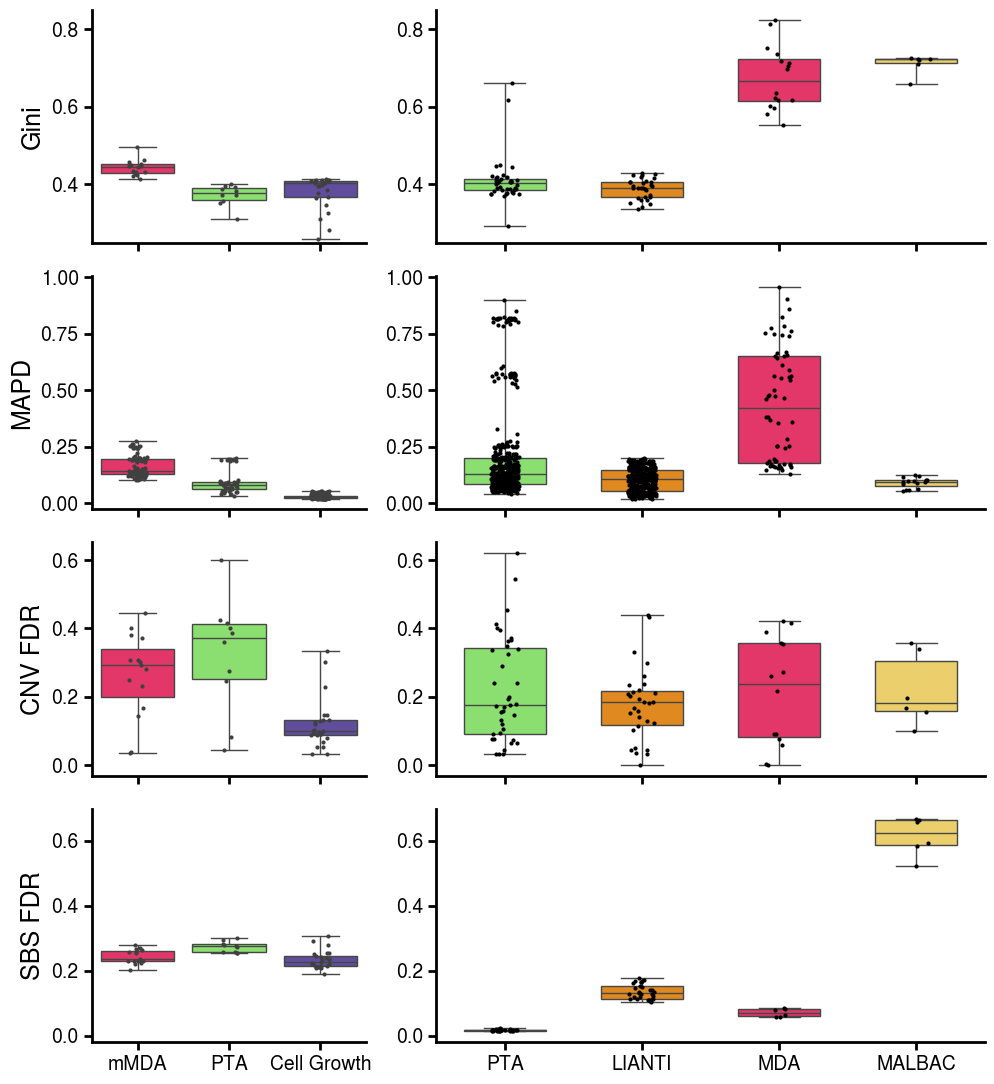

In [13]:
rows = [
    ("Gini",     gini_cap,   gini_pub),
    ("MAPD",     mapd_cap,   mapd_pub),
    ("CNV FDR",  cnv_cap,    cnv_pub),
    ("SBS FDR",  sbs_cap_df, sbs_pub_df),
]

fig, axes = plt.subplots(
    4, 2, figsize=(10, 11),
    gridspec_kw={"width_ratios": [1, 2]},
    sharex='col',
)

for r, (label, df_cap, df_pub) in enumerate(rows):
    # left: CapWGS sub-methods
    ax = axes[r, 0]
    sns.boxplot(data=df_cap, x="method", y="value", order=order_cap,
                ax=ax, hue="method", palette=pub_pal, whis=(0, 100), width=0.8, legend=False)
    sns.stripplot(data=df_cap, x="method", y="value", order=order_cap,
                  ax=ax, size=3, color=".25")
    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=14)
    sns.despine(ax=ax)

    # right: all methods
    ax = axes[r, 1]
    sns.boxplot(data=df_pub, x="method", y="value", order=order_pub,
                ax=ax, hue="method", palette=pub_pal, whis=(0, 100), width=0.6, legend=False)
    sns.stripplot(data=df_pub, x="method", y="value", order=order_pub,
                  ax=ax, size=3, color="black")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=14)
    sns.despine(ax=ax)

    # match y-limits across the two panels in this row
    y0 = min(axes[r, 0].get_ylim()[0], axes[r, 1].get_ylim()[0])
    y1 = max(axes[r, 0].get_ylim()[1], axes[r, 1].get_ylim()[1])
    axes[r, 0].set_ylim(y0, y1)
    axes[r, 1].set_ylim(y0, y1)

# Hide x-tick labels on all but the bottom row
for r in range(3):
    for c in range(2):
        axes[r, c].tick_params(axis="x", labelbottom=False)

# Bottom row: show x-tick labels
for c in range(2):
    axes[3, c].tick_params(axis="x", labelsize=14)

plt.tight_layout()
fig.savefig(RB / "EDF_benchmarking_stack.png", bbox_inches="tight", dpi=600)
plt.show()
